INTRODUCTION:


In modern e-commerce platforms such as amazon,flipkart,myntra users often purchase a wide range of products and share their expereince of the product through reviews.

This reviews consists of valuable information about the customer satisifaction and product quality.

Analysing large amount of reviews manually is time-consuming and ineffecient.Traditional sentiment anlaysis classify the reviews into either positive neutral or negative but failes to provide a detailed overview about specific product features.

In order to overcome the limitation, this project focus on Aspect Based Sentiment Analysis(ASBA) which enables fine-grained analysis by identifying individual product aspects and sentiment assoicated with them.


OBJECTIVE:

The primary objective of this project is to develop an NLP model that:


*   Identify the key aspects of the product from the customer reviews
*   Determine the sentiment[Positive, Negative, Neutral] associate with the product aspect.



In [17]:
#Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

STEP-1: Data Collection

For this project we have collected a real-world dataset of Amazon product reviews from google dataset search.

From this dataset we flitered and selected reviews corresponding to a specific product through ASIN(Amazon Standard Indentification Number).The selected product is Sandisk MicroSD Memory Card which is a storage device commonly used in smartphones, cameras and other electornic devices.

Focusing on a single product helps in consistency in types of aspects mentioned in the review making the aspect based sentiment analysis more meaningful and accurate.



In [7]:
#STEP-2: Data Loading
pd_df=pd.read_csv("amazon_reviews.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2824 entries, 0 to 2823
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      2824 non-null   object 
 1   asin            2824 non-null   object 
 2   reviewerName    2822 non-null   object 
 3   helpful         2823 non-null   object 
 4   reviewText      2822 non-null   object 
 5   overall         2823 non-null   float64
 6   summary         2823 non-null   object 
 7   unixReviewTime  2823 non-null   float64
 8   reviewTime      2823 non-null   object 
 9   day_diff        2823 non-null   float64
 10  helpful_yes     2823 non-null   float64
 11  total_vote      2823 non-null   float64
dtypes: float64(5), object(7)
memory usage: 264.9+ KB


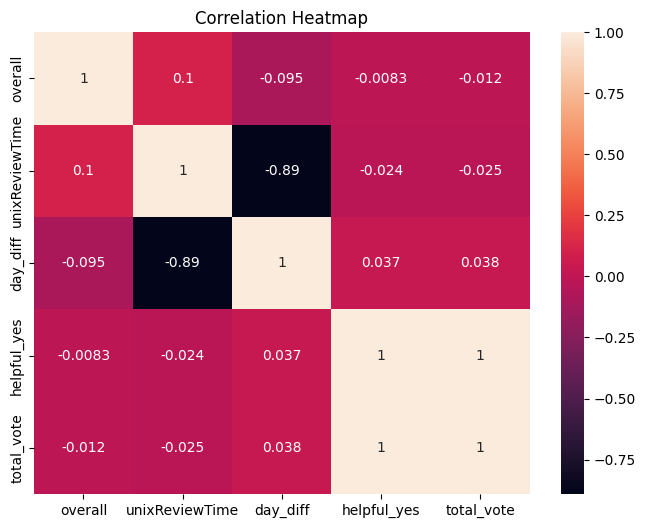

,count
overall,
5.0,2259
4.0,322
1.0,133
3.0,71
2.0,38


In [12]:
#STEP-3: Data Inspection

#1.head() It returns the first five rows of the dataset.
pd_df.head()

#2.tail(): It returns us the last five rows of the dataset.
pd_df.tail()

#3.Shape: It returns us matrix of rows and columns present in the dataset
pd_df.shape

#4.info(): It returns us the columns names and what type of values a column is storing and their non-null count.
pd_df.info()

#5.columns: It returns the column names present in the dataset.
pd_df.columns

#6.describe():It gives statistical summary of the columns such as mean, median std etc..
pd_df.describe()
pd_df.describe(include="object")

#7.Correlation analysis:
pd_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(pd_df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#8.nunique():It gives us the number of unqiue values present in the columns
pd_df.nunique()

#9.Value_counts():It gives the distribution of the dataset and from this we check whether the dataset is balanced or imbalanced.
pd_df["overall"].value_counts()

Insights from Data Inspection:

1. From head we have made sure that the data is loaded sucessfully and checked the columns are present correctly rather than any row specification.

2. From tail we have got clarity that the entire dataset is loaded.

3. From shape we get to know that there are 4915 rows and 12 columns are present

4. From info we understood that  there are missing values present in reviewText and reviewerName  and reviewTime is stored as object instead of datetime64

5. Object:
 From describe we understood that
 *  reviewerID freq is 1 which means every value is different and these coulmns can be removed as model cannot learn anything.
  *  same with asin it is just one value which represnts that the reviews are of same  product and these can also be removed as it doesnt help models to learn anything.
  *  as per our project reviewer name doesnt help us so we can even remove it.

6. Since unixReviewTime and day_diff are highly correlated, day_diff is removed to reduce redundancy and multicollinearity..

7.From value_counts we can clearly observe that the dataset is imbalanced F1-score is considered the primary evaluation metric because it provides a balanced measure of precision and recall.

In [13]:
#STEP-4 Data Cleaning

#1.Remove Uncessary or irrelvant Columns
'''From Data Inspection we have concluded that asin, revieweid ,reviewename,day_diff should be removed.'''
pd_df=pd_df.drop(columns=["asin","reviewerID","reviewerName","day_diff"],axis=1)

#2.Checking missing values
pd_df.isnull().sum()
'''From above we can clearly see that there is only one missing value in reviewText column we drop that row directly.'''
pd_df.dropna(inplace=True)


#3.Checking Duplicate values
pd_df.duplicated().sum()
'''There are no duplicate values present in the dataset.'''

#4.Check the datatype format
'''From data inspection we have observerd that the reviewtime is stored wrongly so we convert it to datetime format.'''
pd_df["reviewTime"]=pd.to_datetime(pd_df["reviewTime"])

#5.Removing Data Leakage Columns
'''From the dataset we have observed that the summary column is directly telling the aspect and the sentiment attached to it which is leakage due to this there is a chance of model cheating
by just remembering this column so yes that is why we remvoe this column.'''
pd_df.drop(columns=["summary"],axis=1,inplace=True)



In [18]:
#Step-5:Text Pre-Processing.

#1. Lowercasing: Converting the entire text into lower-case.
'''All review text is converted to lowercase to ensure uniformity. This helps in treating words like “Good” and “good” as the same token,
   thereby reducing redundancy and improving model performance.'''

pd_df['reviewText']=pd_df['reviewText'].str.lower()
pd_df.head()

#2. Checking and Removing if there is a presence of HTML tags.
def check_html(text):
  return bool(re.search(r'<.*?>',text))
checking=pd_df["reviewText"].apply(check_html).unique()
print(checking)
'''Conclusion: There are no HTML tags present in the dataset'''

#3.Checking and removing if there is a presence of URL tags.
def check_url(text):
  return bool(re.search(r'https?://\S+|www\.\S+',text))
checking=pd_df["reviewText"].apply(check_url).unique()
print(checking)
print(pd_df["reviewText"].apply(check_url).value_counts())
'''Conclusion: From the output we have confirmed that there are url's present in the dataset.
   So before blindly deleting them we check whether the urls holds any information or just random noise then decide what to do.'''
url_rows = pd_df[pd_df["reviewText"].apply(check_url)]
print(url_rows["reviewText"])
''' Here  we have checked manually the urls doesnot contain any information so we decided to delete it directly.'''
def sub_url(text):
  return re.sub(r'https?://\S+|www\.\S+','',text)
pd_df["reviewText"]=pd_df["reviewText"].apply(sub_url);


#4.Checking and removing Punctations
def check_punch(text):
  return bool(re.search(r'[@#$%^&*]',text));
checking=pd_df["reviewText"].apply(check_punch)
print(checking.value_counts())

def remove_punch(text):
  return re.sub(r'[@^#$%&*]'," ",text)
pd_df['reviewText']=pd_df['reviewText'].apply(remove_punch)


#5. Converting Punctations

def convert_punctuation(text):
    text = re.sub(r'!{2,}', ' <STRONG> ', text)
    text = re.sub(r'!', ' <EMPHASIS> ', text)

    text = re.sub(r'\?{2,}', ' <QUESTION_STRONG> ', text)
    text = re.sub(r'\?', ' <QUESTION> ', text)

    text = re.sub(r'\.{3,}', ' <UNCERTAIN> ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text
pd_df["reviewText"]=pd_df['reviewText'].apply(convert_punctuation)


#6.Stopwoord Removal

nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
important_words = {'not', 'no', 'but', 'very'}

stop_words = stop_words - important_words
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word.lower() not in stop_words])
pd_df['reviewText'] = pd_df['reviewText'].apply(remove_stopwords)

[False  True]
[False]
reviewText
False    2822
Name: count, dtype: int64
Series([], Name: reviewText, dtype: object)
reviewText
False    2822
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
